In [1]:
!pip install --upgrade ipython jupyter
!pip install -U bitsandbytes>=0.46.1
%load_ext autoreload
%autoreload 2

def refresh_repo():
    %cd /kaggle/working
    %rm -rf from-neurons-to-directions
    !git clone https://github.com/jefri021/from-neurons-to-directions.git
    %cd /kaggle/working/from-neurons-to-directions/
    !git pull origin main

refresh_repo()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.9/630.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.15.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
ERROR: pip's dependency resolver does not currently ta

# 04 — Experiment 2: Causal Bridge

**Research question:**
  Does ablating safety neurons causally destroy the refusal direction?

Experiment 1 asked a geometric question: do safety neurons SPAN r?
Experiment 2 asks a causal question: do safety neurons GENERATE r?

These are different. A set of vectors can span a direction without
being its cause — they might just happen to point the same way.
Causality requires that removing the neurons actually changes r.

The experiment:
  1. Collect residual stream activations normally → compute r (original)
  2. Collect residual stream activations WITH safety neurons zeroed out
     → compute r_ablated
  3. Compare r and r_ablated layer by layer (cosine similarity)

If cosine similarity drops after ablation → neurons were generating r
If cosine similarity stays high          → r comes from elsewhere

We also check the behavioral consequence: does ablating neurons drop
refusal the same way ablating r did in notebook 01? And does injecting
r (Paper 1's method) still work after neurons are ablated?

**Expected runtime:** ~25 minutes
  - Activation collection with ablation : ~15 min
  - Generation tests                    : ~10 min

## 0. Imports

In [ ]:
import sys
sys.path.insert(0, "/kaggle/working/from-neurons-to-directions/src")

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from model_utils import (
    load_model_and_tokenizer,
    apply_chat_template,
    get_num_layers,
    generate,
)
from activation_store import ActivationStore
from refusal_direction import (
    compute_refusal_direction,
    generate_with_ablation,
    generate_with_addition,
)
from safety_neurons import (
    get_top_safety_neurons,
    collect_activations_with_neuron_ablation,
    generate_with_neuron_ablation,
)
from metrics import (
    refusal_rate,
    direction_alignment,
    cosine_similarity_1d,
)
from viz import (
    plot_direction_survival,
    plot_survival_with_null_band,
    plot_layer_alignment,
)
from null_distribution import *

print("Imports OK")

Imports OK


## 1. Load saved results from previous notebooks

In [3]:
directions  = torch.load("/kaggle/working/from-neurons-to-directions/data/directions.pt",       map_location="cpu")
best_data   = torch.load("/kaggle/working/from-neurons-to-directions/data/best_direction.pt",   map_location="cpu")
scores      = torch.load("/kaggle/working/from-neurons-to-directions/data/change_scores.pt",    map_location="cpu")

best_layer  = best_data["layer"]
best_r      = best_data["direction"]
best_pos    = best_data["position"]

print(f"Directions loaded : {len(directions)} layers")
print(f"Best layer        : {best_layer}")
print(f"Best r norm       : {best_r.norm():.4f}")
print(f"Best position     : {best_pos}")

Directions loaded : 1624 layers
Best layer        : 16
Best r norm       : 62.4757
Best position     : -4


## 2. Load instruct model and prompts

In [4]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

model, tokenizer = load_model_and_tokenizer("qwen_instruct")
n_layers = get_num_layers(model)

hf_token = UserSecretsClient().get_secret("HF-READ")

harmful_ds = load_dataset("walledai/AdvBench", token=hf_token)
harmless_ds = load_dataset("tatsu-lab/alpaca", token=hf_token)

harmful = harmful_ds["train"]
harmless = harmless_ds["train"]

harmful_prompts_raw = harmful["prompt"]

# Keep only Alpaca samples with empty input field
harmless_prompts_raw = [
    instruction
    for instruction, inp in zip(harmless["instruction"], harmless["input"])
    if inp.strip() == ""
]

n = min(len(harmful_prompts_raw), len(harmless_prompts_raw))

harmful_prompts_raw = harmful_prompts_raw[:n]
harmless_prompts_raw = harmless_prompts_raw[:n]

print(f"Harmful prompts  : {len(harmful_prompts_raw)}")
print(f"Harmless prompts : {len(harmless_prompts_raw)}")

harmful_prompts  = [apply_chat_template(p, tokenizer) for p in harmful_prompts_raw]
harmless_prompts = [apply_chat_template(p, tokenizer) for p in harmless_prompts_raw]

top_neurons = get_top_safety_neurons(scores, k=500)
print(f"\nTop-500 safety neurons ready.")

cand_layers = list(range(n_layers))

Loading 'qwen_instruct' from /kaggle/input/models/qwen-lm/qwen2.5/transformers/7b-instruct/1 ...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  7.6B parameters | devices: {'cuda:0', 'cuda:1'}


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/35.1k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/520 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Harmful prompts  : 520
Harmless prompts : 520
Top-500 safety neurons selected.
  Layer distribution (top 10 layers by count): {27: 345, 26: 99, 25: 23, 24: 14, 23: 9, 22: 7, 21: 1, 19: 1, 18: 1}

Top-500 safety neurons ready.


## 3. Collect residual stream activations — normal (no ablation)

First we collect the baseline residual stream activations, from which
we recompute r. This should match the directions from notebook 01.
If it does, it confirms our pipeline is reproducible.

We load from disk if already saved (notebook 01 collected these).
If not, we collect them fresh here.

In [5]:
try:
    harmful_acts_normal  = ActivationStore.load(
        "/kaggle/working/from-neurons-to-directions/data/harmful_residual.pt"
    )
    harmless_acts_normal = ActivationStore.load(
        "/kaggle/working/from-neurons-to-directions/data/harmless_residual.pt"
    )
    print("Loaded existing residual activations from notebook 01.")
except Exception:
    print("Residual activations not found — collecting fresh...")
    store = ActivationStore(model, tokenizer,
                            save_dir="/kaggle/working/from-neurons-to-directions/activations/instruct")

    store.collect(harmful_prompts,  mode="residual", layers=cand_layers,
                  tag="harmful",  batch_size=64)
    store.save()
    store.collect(harmless_prompts, mode="residual", layers=cand_layers,
                  tag="harmless", batch_size=64)
    store.save()

    harmful_acts_normal  = ActivationStore.load(
        "/kaggle/working/from-neurons-to-directions/activations/instruct/harmful_residual.pt"
    )
    harmless_acts_normal = ActivationStore.load(
        "/kaggle/working/from-neurons-to-directions/activations/instruct/harmless_residual.pt"
    )

# Recompute directions as a reproducibility check
directions_check = compute_refusal_direction(
    harmful_acts_normal, harmless_acts_normal, normalize=True
)

# Verify against notebook 01's directions
sim_check = cosine_similarity_1d(directions_check[(best_layer, best_pos)], directions[(best_layer, best_pos)])
print(f"\nReproducibility check — cosine sim of r at {(best_layer, best_pos)}: {sim_check:.6f}")
print("(Should be ≈ 1.0 — confirms pipeline is deterministic)")

Residual activations not found — collecting fresh...


100%|██████████| 9/9 [02:53<00:00, 19.23s/it]


  Done. Tensor shapes: {'residual_0': [520, 58, 3584], 'residual_1': [520, 58, 3584], 'residual_2': [520, 58, 3584], 'residual_3': [520, 58, 3584], 'residual_4': [520, 58, 3584], 'residual_5': [520, 58, 3584], 'residual_6': [520, 58, 3584], 'residual_7': [520, 58, 3584], 'residual_8': [520, 58, 3584], 'residual_9': [520, 58, 3584], 'residual_10': [520, 58, 3584], 'residual_11': [520, 58, 3584], 'residual_12': [520, 58, 3584], 'residual_13': [520, 58, 3584], 'residual_14': [520, 58, 3584], 'residual_15': [520, 58, 3584], 'residual_16': [520, 58, 3584], 'residual_17': [520, 58, 3584], 'residual_18': [520, 58, 3584], 'residual_19': [520, 58, 3584], 'residual_20': [520, 58, 3584], 'residual_21': [520, 58, 3584], 'residual_22': [520, 58, 3584], 'residual_23': [520, 58, 3584], 'residual_24': [520, 58, 3584], 'residual_25': [520, 58, 3584], 'residual_26': [520, 58, 3584], 'residual_27': [520, 58, 3584]}
Saved → /kaggle/working/from-neurons-to-directions/activations/instruct/harmful_residual.p

100%|██████████| 9/9 [03:22<00:00, 22.46s/it]


  Done. Tensor shapes: {'residual_0': [520, 70, 3584], 'residual_1': [520, 70, 3584], 'residual_2': [520, 70, 3584], 'residual_3': [520, 70, 3584], 'residual_4': [520, 70, 3584], 'residual_5': [520, 70, 3584], 'residual_6': [520, 70, 3584], 'residual_7': [520, 70, 3584], 'residual_8': [520, 70, 3584], 'residual_9': [520, 70, 3584], 'residual_10': [520, 70, 3584], 'residual_11': [520, 70, 3584], 'residual_12': [520, 70, 3584], 'residual_13': [520, 70, 3584], 'residual_14': [520, 70, 3584], 'residual_15': [520, 70, 3584], 'residual_16': [520, 70, 3584], 'residual_17': [520, 70, 3584], 'residual_18': [520, 70, 3584], 'residual_19': [520, 70, 3584], 'residual_20': [520, 70, 3584], 'residual_21': [520, 70, 3584], 'residual_22': [520, 70, 3584], 'residual_23': [520, 70, 3584], 'residual_24': [520, 70, 3584], 'residual_25': [520, 70, 3584], 'residual_26': [520, 70, 3584], 'residual_27': [520, 70, 3584]}
Saved → /kaggle/working/from-neurons-to-directions/activations/instruct/harmless_residual.

## 4. Collect residual stream activations — WITH neuron ablation

This is the key intervention of Experiment 2.

We run the same prompts through the instruct model, but with the
safety neurons zeroed out during the forward pass. The residual stream
activations we capture reflect what the model "thinks" after safety
neurons have been silenced.

We then recompute r from these ablated activations and compare to
the original r.

In [6]:
print("Collecting residual stream activations WITH safety neurons ablated...")
print("(This runs two sets of forward passes — takes ~10 minutes)\n")

# Harmful prompts — ablated
harmful_acts_ablated = collect_activations_with_neuron_ablation(
    model=model,
    tokenizer=tokenizer,
    prompts=harmful_prompts,
    safety_neurons=top_neurons,
    layers=cand_layers,
)

# Harmless prompts — ablated
harmless_acts_ablated = collect_activations_with_neuron_ablation(
    model=model,
    tokenizer=tokenizer,
    prompts=harmless_prompts,
    safety_neurons=top_neurons,
    layers=cand_layers,
)

torch.save(harmful_acts_ablated,
           "/kaggle/working/from-neurons-to-directions/activations/instruct/harmful_residual_ablated.pt")
torch.save(harmless_acts_ablated,
           "/kaggle/working/from-neurons-to-directions/activations/instruct/harmless_residual_ablated.pt")
print("Ablated activations saved.")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


(This runs two sets of forward passes — takes ~10 minutes)

Ablated activations saved.


## 5. Recompute refusal direction from ablated activations

If safety neurons are the source of r, then the refusal direction
computed from ablated activations should be:
  - Weaker (lower norm) — less signal
  - Misaligned with the original r (different direction)

If r survives ablation with high cosine similarity to the original,
it means r is generated by something other than safety neurons.

In [7]:
directions_ablated = compute_refusal_direction(
    harmful_acts_ablated, harmless_acts_ablated, normalize=True
)

print(f"Ablated directions computed for {len(directions_ablated)} layers.")

# Per-layer cosine similarity: original r vs ablated r
sims_original = {l: 1.0 for l in directions}          # original vs itself = 1
sims_ablated  = direction_alignment(directions, directions_ablated)

print(f"\nPer-layer cosine similarity (original r vs ablated r):")
print(f"{'Layer':<8} {'Cosine sim':>12}  {'Interpretation'}")
print("-" * 55)
print(sims_ablated)
for layer_pos in sorted(sims_ablated.keys()):
    sim = sims_ablated[layer_pos]
    interp = ("strong survival" if sim > 0.8
              else "partial survival" if sim > 0.4
              else "largely destroyed")
    print(f"{layer_pos} {sim:>12.4f}  {interp}")

torch.save(sims_ablated,
           "/kaggle/working/from-neurons-to-directions/direction_survival.pt")
print("\nSaved → results/direction_survival.pt")

Computed directions for 28 (layer, position) pairs.
Ablated directions computed for 28 layers.

Per-layer cosine similarity (original r vs ablated r):
Layer      Cosine sim  Interpretation
-------------------------------------------------------
{(0, -1): 0.11984153091907501, (1, -1): 0.1350136697292328, (2, -1): 0.09924700856208801, (3, -1): 0.1342216581106186, (4, -1): 0.14128977060317993, (5, -1): 0.15200932323932648, (6, -1): 0.1359572410583496, (7, -1): 0.12953630089759827, (8, -1): 0.11365515738725662, (9, -1): 0.0969383642077446, (10, -1): 0.07448645681142807, (11, -1): 0.0806700810790062, (12, -1): 0.060055237263441086, (13, -1): 0.07584701478481293, (14, -1): 0.05830686166882515, (15, -1): 0.04458920657634735, (16, -1): 0.033571332693099976, (17, -1): 0.038329824805259705, (18, -1): 0.03187565132975578, (19, -1): 0.041491370648145676, (20, -1): 0.03099808096885681, (21, -1): 0.04564199969172478, (22, -1): 0.03840656951069832, (23, -1): 0.023318912833929062, (24, -1): 0.01488586

## 6. Statistical Validation: Null Distribution for Cosine Similarity

**Motivation:**  
In R^d, the cosine similarity between two independent random unit vectors
has mean 0 and standard deviation 1/sqrt(d) — exactly, not asymptotically.  
For Qwen2.5-7B (d = 3584), this SD is ≈ 0.0167, meaning a raw cosine
similarity of 0.082 is already ~4.9 SD from chance — not negligible.

The survival values in Section 5 cannot be read as absolute magnitudes;
they must be compared against this null. We build two baselines:

1. **Theoretical null** — closed-form 1/sqrt(d). Fast but assumes isotropy.
2. **Empirical null** — ablate K random neurons (same K as safety neurons),
   recompute the refusal direction, measure survival. Repeated across seeds.
   This controls for the generic effect of removing ANY K neurons.

The key question: does safety-neuron ablation destroy the refusal direction
**more** than ablating an equal number of random neurons would?

In [ ]:
import sys
sys.path.insert(0, "/kaggle/working/from-neurons-to-directions/src")

from null_distribution import (
    theoretical_null_sd,
    z_score,
    sample_random_neurons,
    summarize_null,
)
from model_utils import get_hidden_size

# ── Theoretical null ───────────────────────────────────────────────────────
d = get_hidden_size(model)          # 3584 for Qwen2.5-7B
null_sd_theoretical = theoretical_null_sd(d)

print(f"Hidden dimension     : {d}")
print(f"Theoretical null SD  : 1/sqrt({d}) = {null_sd_theoretical:.4f}")
print(f"(Two random unit vectors are expected to have |cos sim| < {2*null_sd_theoretical:.4f} with 95% probability)")
print()

# Build a layer-keyed dict of original directions (for pos == -1)
# so it matches sims_ablated_layer_only
original_directions_by_layer = {
    layer: directions[(layer, -1)]
    for layer in range(n_layers)
    if (layer, -1) in directions
}

# Z-score every observed survival value
print(f"Z-scores for observed survival values (safety-neuron ablation):")
print(f"{'Layer':>6} | {'Observed':>10} | {'Z (theor.)':>12} | Interpretation")
print("-" * 65)

sims_ablated_layer_only = {}

for k, v in sims_ablated.items():
    sims_ablated_layer_only[k[0]] = v

for layer in sorted(sims_ablated_layer_only.keys()):
    sim = sims_ablated_layer_only[layer]
    z   = z_score(sim, null_sd_theoretical)
    interp = (
        "< 2σ — not distinguishable from noise"  if z < 2   else
        "2–5σ — weak but real signal"             if z < 5   else
        "5–10σ — moderate signal"                 if z < 10  else
        "> 10σ — strong signal"
    )
    print(f"{layer:>6} | {sim:>10.4f} | {z:>12.1f} | {interp}")

mean_sim = sum(sims_ablated_layer_only.values()) / len(sims_ablated_layer_only)
mean_z   = z_score(mean_sim, null_sd_theoretical)
print()
print(f"Mean survival across layers : {mean_sim:.4f}  ({mean_z:.1f}σ from theoretical null)")
print(f"Best-layer ({best_layer}) survival    : {sims_ablated_layer_only.get(best_layer, float('nan')):.4f}  "
      f"({z_score(sims_ablated_layer_only.get(best_layer, 0), null_sd_theoretical):.1f}σ)")
print()
print("NOTE: Even values labelled 'largely destroyed' in the original plots")
print("are real, non-zero signals in absolute terms. The question for the")
print("empirical null (Cell 3) is whether they are LOWER than what random")
print("ablation of the same size would produce.")

In [ ]:
import torch
import numpy as np

# ── Config ─────────────────────────────────────────────────────────────────
# Each seed runs collect_activations_with_neuron_ablation twice
# (once for harmful, once for harmless). On Kaggle with a P100
# that is roughly 7 min × 2 × n_seeds total.
# Set null_prompt_n < 520 for a faster approximate null.
n_seeds       = 5     # increase to 10 for tighter error bars if time allows
null_prompt_n = 50    # prompts per class; 50 gives a fast run (~14 min total)
                      # set to len(harmful_prompts) for the full-dataset null

k = len(top_neurons)
null_harmful  = harmful_prompts[:null_prompt_n]
null_harmless = harmless_prompts[:null_prompt_n]

print(f"Empirical null config:")
print(f"  Seeds              : {n_seeds}")
print(f"  Prompts per class  : {null_prompt_n}")
print(f"  Random neurons (K) : {k}  (matched to safety neuron count)")
print(f"  Safety neurons excluded from random sampling: yes")
print()

# Accumulate survival per layer across seeds
layers_to_test = sorted(sims_ablated_layer_only.keys())
null_per_layer: dict[int, list[float]] = {l: [] for l in layers_to_test}

for seed in range(n_seeds):
    print(f"\n── Seed {seed+1}/{n_seeds} ──")

    # Sample K random neurons, excluding actual safety neurons
    random_neurons = sample_random_neurons(
        model, k=k, exclude=top_neurons, seed=seed
    )

    # Collect activations with random neurons ablated — harmful prompts
    print("  Collecting (harmful, random ablation)...")
    rand_harmful_acts = collect_activations_with_neuron_ablation(
        model=model,
        tokenizer=tokenizer,
        prompts=null_harmful,
        safety_neurons=random_neurons,
        layers=cand_layers,
    )

    # Collect activations with random neurons ablated — harmless prompts
    print("  Collecting (harmless, random ablation)...")
    rand_harmless_acts = collect_activations_with_neuron_ablation(
        model=model,
        tokenizer=tokenizer,
        prompts=null_harmless,
        safety_neurons=random_neurons,
        layers=cand_layers,
    )

    # Recompute refusal directions from random-ablated activations
    directions_rand_ablated = compute_refusal_direction(
        rand_harmful_acts, rand_harmless_acts, normalize=True
    )

    # Measure cosine similarity with original directions, layer by layer
    for layer in layers_to_test:
        key = (layer, -1)
        if key in directions and key in directions_rand_ablated:
            sim = cosine_similarity_1d(
                directions[key],
                directions_rand_ablated[key]
            )
            null_per_layer[layer].append(sim)

    mean_this_seed = np.mean([
        null_per_layer[l][-1] for l in layers_to_test if null_per_layer[l]
    ])
    print(f"  Mean direction survival (this seed): {mean_this_seed:.4f}")

# Save the null distribution
torch.save(
    null_per_layer,
    "/kaggle/working/from-neurons-to-directions/data/null_per_layer.pt"
)
print(f"\nEmpirical null saved ({n_seeds} seeds × {null_prompt_n} prompts).")
print(f"Overall null mean : {np.mean([v for vals in null_per_layer.values() for v in vals]):.4f}")
print(f"Overall null SD   : {np.std([v for vals in null_per_layer.values() for v in vals]):.4f}")

In [ ]:
import matplotlib.pyplot as plt

# ── Summarize: safety-neuron ablation vs random-ablation null ──────────────
# Negative z-score → safety-neuron ablation is MORE destructive than random.
# Values consistently below the null confirm that the direction loss is
# specific to safety neurons, not a generic K-neuron ablation effect.
print("Safety-neuron ablation vs empirical random-ablation null")
print("(negative z-score = safety ablation more destructive than random)\n")

summarize_null(
    null_per_layer=null_per_layer,
    observed_per_layer=sims_ablated_layer_only,
)

# ── Plot 1: theoretical null band overlay ──────────────────────────────────
fig1 = plot_survival_with_null_band(
    observed_per_layer=sims_ablated_layer_only,
    theoretical_sd=null_sd_theoretical,
    title="Refusal Direction Survival: Safety-Neuron Ablation vs Theoretical Null (±2σ, ±3σ)",
)
fig1.savefig(
    "/kaggle/working/from-neurons-to-directions/plots/exp2_survival_theoretical_null.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ── Plot 2: empirical null band overlay ────────────────────────────────────
fig2 = plot_survival_with_null_band(
    observed_per_layer=sims_ablated_layer_only,
    null_per_layer=null_per_layer,
    title="Refusal Direction Survival: Safety-Neuron vs Random-Neuron Ablation (Mean ±2σ, empirical)",
)
fig2.savefig(
    "/kaggle/working/from-neurons-to-directions/plots/exp2_survival_empirical_null.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ── Final interpretation ───────────────────────────────────────────────────
import numpy as np

null_means = {l: np.mean(null_per_layer[l]) for l in layers_to_test if null_per_layer[l]}
n_below_null_mean = sum(
    1 for l in layers_to_test
    if sims_ablated_layer_only.get(l, 1.0) < null_means.get(l, 0)
)

print(f"\nLayers where safety-neuron ablation is MORE destructive than random null mean:")
print(f"  {n_below_null_mean} / {len(layers_to_test)} layers")
print()

if n_below_null_mean > len(layers_to_test) * 0.7:
    print("Interpretation: Safety-neuron ablation destroys the refusal direction")
    print("specifically — consistently below the random-ablation baseline.")
    print("The direction loss is attributable to the identity of the ablated")
    print("neurons, not just their count.")
elif n_below_null_mean > len(layers_to_test) * 0.4:
    print("Interpretation: Mixed result. Safety-neuron ablation is more destructive")
    print("than random in some layers but not others. The causal claim holds")
    print("partially — some layers' refusal direction is specifically generated")
    print("by safety neurons; in others the effect is generic.")
else:
    print("Interpretation: Safety-neuron ablation is NOT more destructive than")
    print("random ablation of the same size. The direction loss in Section 5.7.1")
    print("is a generic K-neuron ablation effect, not specific to safety neurons.")
    print("This is an important limitation to report in the thesis.")

## 6. Visualize direction survival

This is the central plot of Experiment 2.

Each bar shows how similar the refusal direction is to the original
after safety neurons are ablated. A drop indicates those neurons
were contributing to the direction at that layer.

Saved → /kaggle/working/from-neurons-to-directions/figures/exp2_direction_survival.png


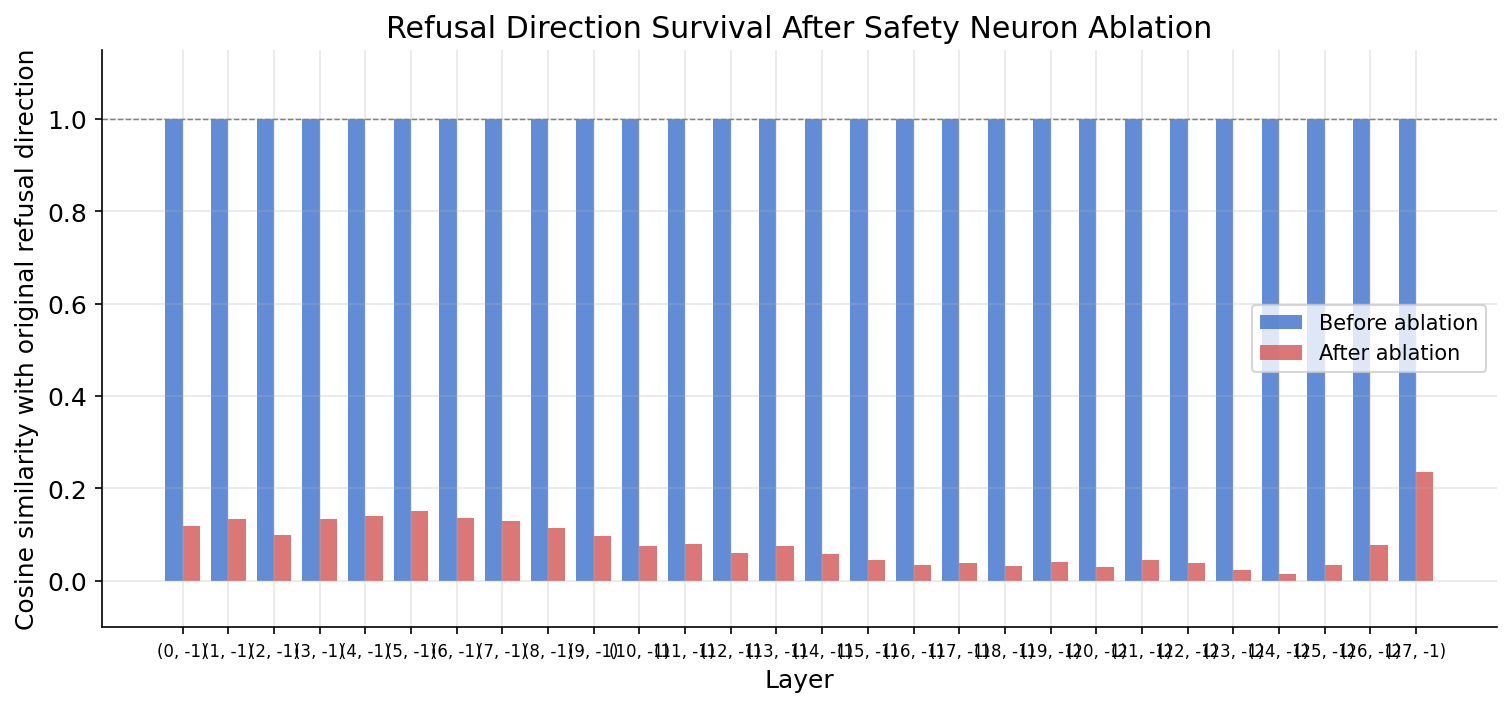

Saved → /kaggle/working/from-neurons-to-directions/figures/exp2_alignment_line.png


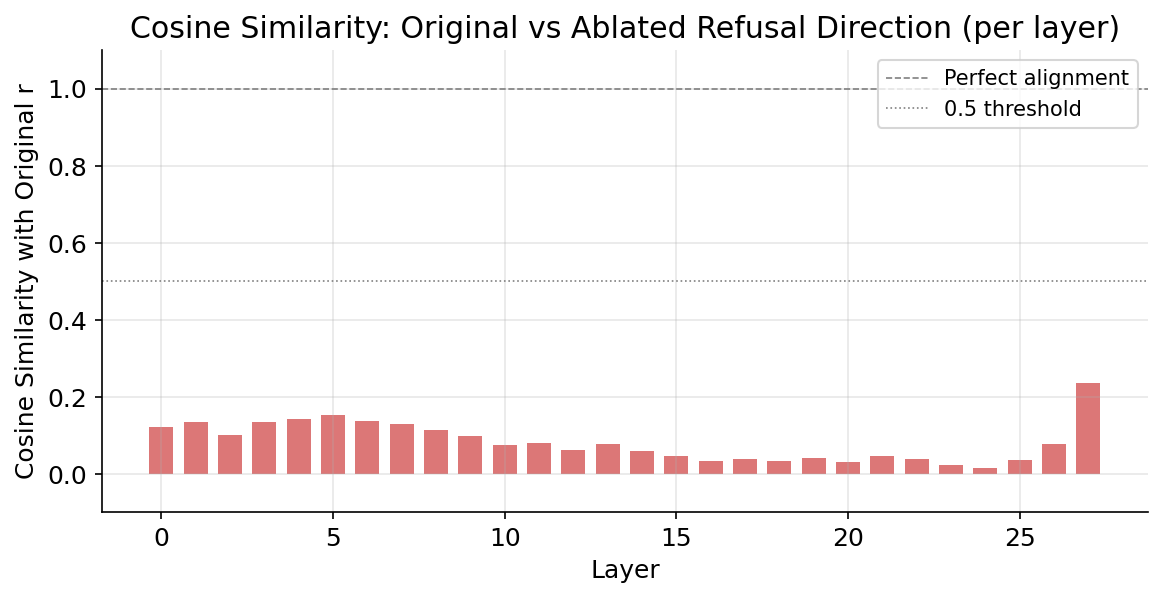

In [8]:
fig = plot_direction_survival(
    original_sims=sims_original,
    ablated_sims=sims_ablated,
    title="Refusal Direction Survival After Safety Neuron Ablation",
    save_path="/kaggle/working/from-neurons-to-directions/figures/exp2_direction_survival.png",
)
plt.show()

sims_ablated_layer_only = {}

for layer_pos, val in sims_ablated.items():
    layer, pos = layer_pos
    if pos == -1:
        sims_ablated_layer_only[layer] = val

# Focused plot: just the ablated similarities as a line
fig2 = plot_layer_alignment(
    similarities=sims_ablated_layer_only,
    title="Cosine Similarity: Original vs Ablated Refusal Direction (per layer)",
    ylabel="Cosine Similarity with Original r",
    save_path="/kaggle/working/from-neurons-to-directions/figures/exp2_alignment_line.png",
)
plt.show()